# Insurance Charges - Modelling
**Input:** ../data/model_ready/

This notebook trains, compares, tunes, and evaluates regression models.

### Training the Baseline Model & Making Predictions

**The Objective:**
We will use Scikit-Learn's `LinearRegression` class to act as our baseline model. Because our dataset is relatively small, this algorithm will use an exact mathematical solver (Singular Value Decomposition) to find the perfect Ordinary Least Squares (OLS) weights without needing iterative Gradient Descent.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
X_train = pd.read_csv('../data/model_ready/X_train.csv')
X_test = pd.read_csv('../data/model_ready/X_test.csv')
y_train = pd.read_csv('../data/model_ready/y_train.csv').squeeze()
y_test = pd.read_csv('../data/model_ready/y_test.csv').squeeze()

In [3]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


###  Model Evaluation & Diagnosing Overfitting

**The Objective:**
We must translate our model's mathematical accuracy into real-world business metrics. We will evaluate the model using three key performance indicators:
1. **$R^2$ (R-Squared):** The percentage of the target's variance explained by our features.
2. **MAE (Mean Absolute Error):** The average dollar amount our predictions are off by.
3. **RMSE (Root Mean Squared Error):** The average error, heavily penalized for massive outliers.

**The Methodology:**
To ensure our model actually learned human biology (and didn't just memorize the data), we will calculate these metrics for **both** the Training Set and the Testing Set. A large gap between these scores indicates **Overfitting**.

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
# we have to wrap MSE in numpy's square root function to get RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))


print(f"{'Metric':<15} | {'Training Set':<20} | {'Testing Set':<20}")
print(f"{'R-Squared (R²)':<15} | {train_r2:<20.4f} | {test_r2:<20.4f}")
print(f"{'MAE':<15} | ${train_mae:<19,.2f} | ${test_mae:<19,.2f}")
print(f"{'RMSE':<15} | ${train_rmse:<19,.2f} | ${test_rmse:<19,.2f}\n")

# Diagnostic check for Overfitting
gap = train_r2 - test_r2
print(f" Diagnostic: The Train/Test R² Gap is {gap:.4f}")
if gap > 0.08:
    print(" Model is memorizing data (Overfitting).")
else:
    print(" Gap is healthy. Model is generalizing well")

Metric          | Training Set         | Testing Set         
R-Squared (R²)  | 0.7351               | 0.8046              
MAE             | $0.28                | $0.27               
RMSE            | $0.45                | $0.40               

 Diagnostic: The Train/Test R² Gap is -0.0695
 Gap is healthy. Model is generalizing well


In [5]:
#the rmse and mae values are very small because we have used log charges, we can use np.exp to convert it into actual charges.

### Coefficient Interpretation

**The Objective:**
Linear Regression allows us to extract the exact mathematical weights assigned to each feature. By examining these coefficients, we can definitively prove which patient attributes drive hospital costs the highest.

*Note: Because our target variable (`charges`) was log-transformed, these coefficients represent the change in the natural log of the cost. Because our continuous variables were Standardized, their coefficients represent the change per standard deviation.*

In [6]:
model.intercept_#this stores the bias(the baseline hospital fee even if there is no age sex or smoking factor)

np.float64(8.493393498603078)

In [7]:
weights = model.coef_#this attribute stores the weights
features = X_train.columns
coefficients_df = pd.DataFrame({
    'Feature': features,
    'Weights': weights
})
coefficients_df

,Feature,Weights
0,age,0.464492
1,is_female,0.078117
2,bmi,0.004836
3,children,0.117271
4,is_smoker,1.451890
5,region_northwest,-0.045990
6,region_southeast,-0.121695
7,region_southwest,-0.103104
8,bmi_category_Normal,0.231686
9,bmi_category_Overweight,0.284918


Text(0, 0.5, 'Frequency')

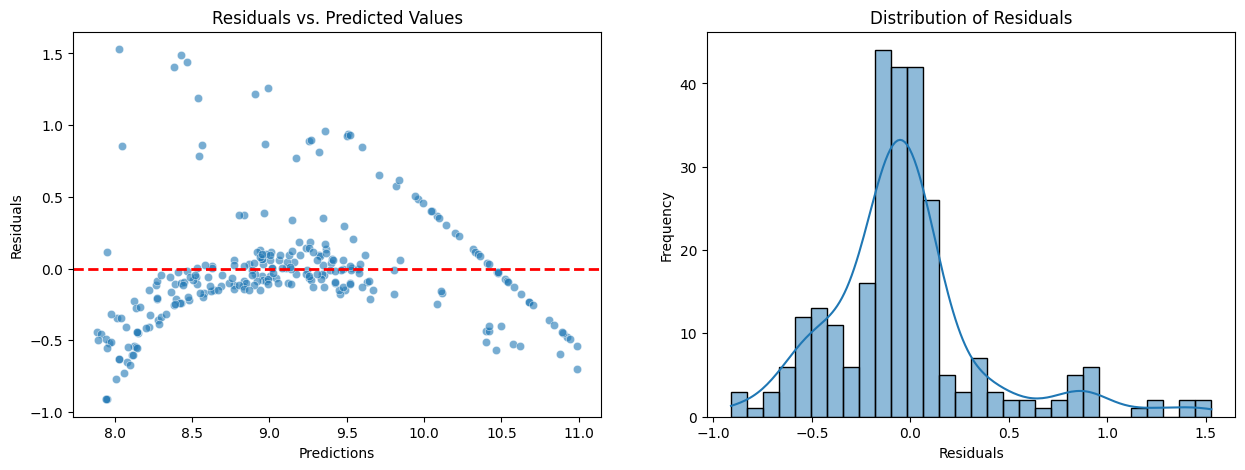

In [8]:
residuals = y_test - y_test_pred
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ----------------------------------------------------
# PLOT 1: Residuals vs. Predicted (The Scatter Plot)
# ----------------------------------------------------
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.6, ax=axes[0])
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs. Predicted Values')
axes[0].set_xlabel('Predictions')
axes[0].set_ylabel('Residuals')


# ----------------------------------------------------
# PLOT 2: Residual Distribution (The Histogram)
# ----------------------------------------------------
sns.histplot(residuals, kde=True, ax=axes[1], bins=30)

axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')


### Non-Linear Modeling (The Decision Tree)

**The Objective:**
Linear Regression assumes a perfectly straight mathematical relationship. However, human biology often involves thresholds and conditions (e.g., gaining BMI only drastically affects costs *if* the patient is also a smoker). To capture this "If-This-Then-That" logic, we will train a **Decision Tree Regressor**.

**How it works:**
Instead of using weights and calculus, a Decision Tree acts like a giant game of 20 Questions.
1. **Root Node:** Starts with 100% of the training patients.
2. **Decision Nodes:** The algorithm asks Yes/No questions (e.g., `is_smoker == 1?`) to split the patients into increasingly pure buckets by minimizing the MSE.
3. **Leaf Nodes:** The final buckets. When a new patient lands in a leaf node, their predicted medical bill is simply the average bill of all the training patients in that bucket.

**The Danger:**
If left unconstrained, a Decision Tree will suffer from extreme **High Variance (Overfitting)**. It will keep asking questions until every training patient has their own custom bucket, resulting in a perfect training score but catastrophic real-world performance. Let's prove this by training an unconstrained tree.

In [9]:
#lets build the model
from sklearn.tree import DecisionTreeRegressor
tree_model = DecisionTreeRegressor(random_state = 42)
#random state ensures that every same question is followed everytime we run this
tree_model.fit(X_train,y_train)
max_depth = tree_model.get_depth()
total_leaves = tree_model.get_n_leaves()

print("depth of the tree" ,max_depth)
print("no. of leaves are ",total_leaves)

#lets evaluate this using r2 score
#right now our model is having one or two patient in every single bucket,hence it has memorized the training data

tree_train_pred = tree_model.predict(X_train)
tree_train_r2 = r2_score(y_train, tree_train_pred)

tree_test_pred = tree_model.predict(X_test)
tree_test_r2 = r2_score(y_test, tree_test_pred)

print(f"Training R²: {tree_train_r2:.4f}")
print(f"Testing R²:  {tree_test_r2:.4f}")
print(f"Gap:         {tree_train_r2 - tree_test_r2:.4f}")



depth of the tree 19
no. of leaves are  979
Training R²: 1.0000
Testing R²:  0.6242
Gap:         0.3758


### Hyperparameter Tuning via GridSearchCV

To combat overfitting, we must constrain the tree. We will use `GridSearchCV` to perform 5-fold cross-validation across a grid of hyperparameters:
- `max_depth`: Limits how deep the tree can grow.
- `min_samples_leaf`: The minimum number of samples required to be at a leaf node (prevents creating buckets with only 1-2 patients).
- `min_samples_split`: The minimum number of samples required to split an internal node.

In [10]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter search space
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10, 20]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Run the search
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print(f"Best CV R² Score: {grid_search.best_score_:.4f}")

Best Hyperparameters: {'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV R² Score: 0.7853


### Evaluating the Tuned Decision Tree

Let's extract the best estimator found by our grid search, inspect its size (depth and leaf count), and check if the gap between train and test scores has improved.

In [11]:
best_tree = grid_search.best_estimator_

# Get tree characteristics
tuned_depth = best_tree.get_depth()
tuned_leaves = best_tree.get_n_leaves()

# Evaluate performance
tuned_train_pred = best_tree.predict(X_train)
tuned_train_r2 = r2_score(y_train, tuned_train_pred)

tuned_test_pred = best_tree.predict(X_test)
tuned_test_r2 = r2_score(y_test, tuned_test_pred)

print(f"Tuned Tree Depth:  {tuned_depth}")
print(f"Tuned Tree Leaves: {tuned_leaves}")
print(f"Training R²:       {tuned_train_r2:.4f}")
print(f"Testing R²:        {tuned_test_r2:.4f}")
print(f"Generalization Gap: {tuned_train_r2 - tuned_test_r2:.4f}")

Tuned Tree Depth:  4
Tuned Tree Leaves: 15
Training R²:       0.8095
Testing R²:        0.8570
Generalization Gap: -0.0475
